# Download VizDoom and Other Packages

In [ ]:
#git clone https://github.com/Farama-Foundation/ViZDoom.git


#pip install vizdoom
#pip install gym
#pip install opencv-python
#pip install matplotlib
#pip install numpy
#pip install keyboard
#pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
#pip install stable-baselines3[extra]
#pip install ultralytics

# Import Dependicies

In [1]:
from vizdoom import * 
import os
import random
import time 
import numpy as np
import keyboard
from matplotlib import pyplot as plt

from ultralytics import YOLO
import torch

import cv2
from gymnasium  import Env
from gymnasium.spaces import Discrete, Box

from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common import env_checker
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# Setup Game and Play Random Actions (For Test)

In [2]:
config_file_path = "originalGithubRepo/ViZDoom/scenarios/basic.cfg"

game  = DoomGame()
game.load_config(config_file_path)

game.set_screen_resolution(ScreenResolution.RES_320X240)
game.set_labels_buffer_enabled(True)
game.set_depth_buffer_enabled(True)

game.init()
actions = np.identity(game.get_available_buttons_size(), dtype=np.uint8)

In [ ]:
isGameRunning = True
episodes = 10
for episode in range(episodes):
    print("Episode #" + str(episode + 1))
    game.new_episode()
    while not game.is_episode_finished() and isGameRunning:
        state = game.get_state()
        img = state.screen_buffer
        info = state.game_variables
        reward = game.make_action(random.choice(actions), 4)
        print("Reward:", reward)
        time.sleep(0.02)
        if keyboard.is_pressed("-"):
            isGameRunning = False
            break
    ##############################    
    print("Episode finished!")
    print("Total reward:", game.get_total_reward())
    if not isGameRunning:
        print("Game closed by user!")
        game.close()
        break
    time.sleep(2)

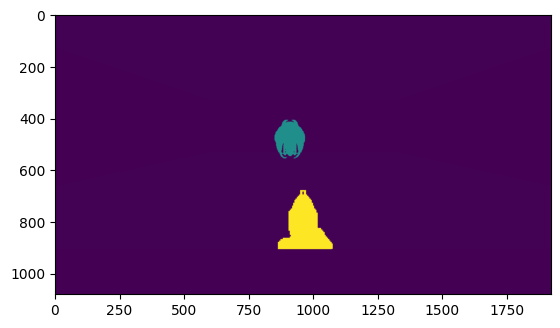

In [7]:
game.get_state().screen_buffer.shape
labels = game.get_state().labels_buffer
if labels is not None:
    plt.imshow(labels)


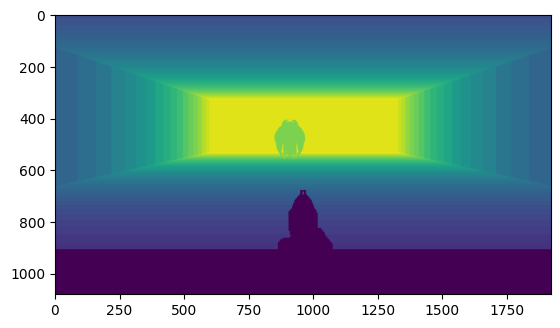

In [8]:
depth = game.get_state().depth_buffer
if depth is not None:
    plt.imshow(depth)

In [4]:
game.close()

# VizDoom Gym Environment

In [2]:
class VizDoomGym(Env):
    def __init__(self, render = False, renderRes = ScreenResolution.RES_320X240, cfp = "originalGithubRepo/ViZDoom/scenarios/basic.cfg", new_shape=(100,160,1), cut_bottom=20,
                dino_model="dinov2_vits14", dino_imgsz=224, dino_every_n=1):
        
        super().__init__()
        self.game  = DoomGame()
        self.game.load_config(cfp)

        self.new_shape = new_shape
        self.cut_bottom = cut_bottom

        self.dino_every_n = max(1, int(dino_every_n))
        self.dino_imgsz = int(dino_imgsz)
        self._dino_frame_i = 0
        self._last_dino_obs = np.zeros(self.new_shape, dtype=np.uint8)
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.dino = torch.hub.load("facebookresearch/dinov2", dino_model)
        self.dino.eval().to(self.device)

        if render:
            self.game.set_screen_resolution(renderRes)
            self.game.set_window_visible(True)
        else:
            self.game.set_window_visible(False)

        self.game.init()

        self.observation_space = Box(low=0, high=255, shape=self.new_shape, dtype=np.uint8)
        #self.observation_space = Box(low=0, high=255, shape=self.game.get_state().screen_buffer.shape, dtype=np.uint8)
        print(str(self.game.get_available_buttons_size()) + " actions available.")
        self.action_space = Discrete(self.game.get_available_buttons_size())
        self.actions = np.identity(self.game.get_available_buttons_size(), dtype=np.uint8)
        
    def step(self, action):
        reward = self.game.make_action(self.actions[action], 4)
        truncated = False  # set True if you add time-limit logic
        
        if self.game.get_state():
            state = self.game.get_state()
            screen_buff = state.screen_buffer #next frame
            screen_buff = self.process_screen(screen_buff)
            
            ammo = state.game_variables[0]
            info = ammo
        else:
            screen_buff = np.zeros(self.observation_space.shape, dtype=np.uint8)
            info = 0

        info = {"info":info}

        done = self.game.is_episode_finished()
        return screen_buff, reward, done, truncated, info

    def render(self):
        pass
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.game.new_episode()
        screen_buff = self.game.get_state().screen_buffer
        obs = self.process_screen(screen_buff)
        ammo = self.game.get_state().game_variables[0]
        info = {"info": ammo}
        return obs,info
     
    def process_screen(self, frame):
        self._dino_frame_i += 1
        if self._dino_frame_i % self.dino_every_n != 0:
            return self._last_dino_obs.copy()

        obs = self.process_screen_dino(frame)
        self._last_dino_obs = obs
        return obs
    
    @torch.no_grad()
    def process_screen_dino(self, frame):
        img_bgr = np.moveaxis(frame, 0, -1).astype(np.uint8)
        img_bgr = cv2.resize(img_bgr, (self.new_shape[1], self.new_shape[0]+self.cut_bottom), interpolation=cv2.INTER_CUBIC)
        if self.cut_bottom > 0:
            img_bgr = img_bgr[:-self.cut_bottom, :]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        img_rgb = cv2.resize(img_rgb, (self.dino_imgsz, self.dino_imgsz), interpolation=cv2.INTER_AREA)

        # To torch (1,3,H,W), float [0,1]
        x = torch.from_numpy(img_rgb).permute(2, 0, 1).unsqueeze(0).float() / 255.0
        x = x.to(self.device)

        # Extract last-layer patch tokens as a spatial feature map
        # get_intermediate_layers(..., reshape=True) -> (B, C, Hpatch, Wpatch)
        feat = self.dino.get_intermediate_layers(x, n=1, reshape=True)[0]  # :contentReference[oaicite:4]{index=4}
        feat = feat.squeeze(0)  # (C, Hpatch, Wpatch)

        # Convert to 1-channel "energy map": L2 norm across channels
        energy = torch.linalg.vector_norm(feat, dim=0)  # (Hpatch, Wpatch)

        # Normalize to [0,255] uint8 (important for SB3 CNN policies) :contentReference[oaicite:5]{index=5}
        e = energy.detach().cpu().numpy()
        e = (e - e.min()) / (e.max() - e.min() + 1e-8)
        e = (e * 255.0).astype(np.uint8)

        e = cv2.resize(e, (self.new_shape[1], self.new_shape[0]), interpolation=cv2.INTER_CUBIC);
        return e[..., np.newaxis]  # (H,W,1) uint8
        
    def close(self):
        self.game.close()

In [6]:
config_file_path = "originalGithubRepo/ViZDoom/scenarios/basic.cfg"
env = VizDoomGym(render=True, cfp=config_file_path, new_shape=(100,160,1), cut_bottom=20)
env_checker.check_env(env)

Using cache found in C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


3 actions available.


In [ ]:
env.step(2)

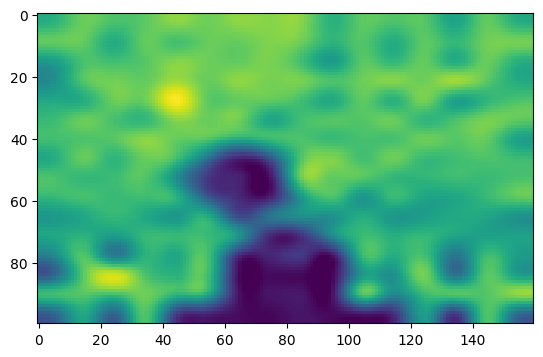

In [32]:
obs, _ = env.reset()
plt.imshow(obs)

In [33]:
env.close()

# Setup Callback

In [3]:
class TrainAndLoggingCallback(BaseCallback):

    def __init__(self, check_freq, save_path, verbose=1):
        super(TrainAndLoggingCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.save_path = save_path

    def _init_callback(self):
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self):
        if self.n_calls % self.check_freq == 0:
            model_path = os.path.join(self.save_path, 'best_model_{}'.format(self.n_calls))
            self.model.save(model_path)

        return True

In [4]:
CHECKPOINT_DIR = './train/train_basic_vitdino/'
LOG_DIR = './logs/log_basic_vitdino/'
CONFIG_FILE_PATH = "originalGithubRepo/ViZDoom/scenarios/basic.cfg"

In [5]:
callback = TrainAndLoggingCallback(check_freq=10000, save_path=CHECKPOINT_DIR)

# Train Model

In [39]:
env = VizDoomGym(render=False, cfp=CONFIG_FILE_PATH, new_shape=(100,160,1), cut_bottom=20)

Using cache found in C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main


3 actions available.


In [40]:
model = PPO('CnnPolicy', env, verbose=1, tensorboard_log=LOG_DIR, learning_rate=0.0001, n_steps=2048)

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Wrapping the env in a VecTransposeImage.


In [ ]:
model.learn(total_timesteps=100000, callback=callback)

# Test the Model

In [6]:
model = PPO.load('./train/train_basic_vitdino/best_model_50000')
env = VizDoomGym(render=True,renderRes=ScreenResolution.RES_320X240)
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=1)
print(f'Mean reward: {mean_reward} +/- {std_reward}')


Using cache found in C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\Mehmet/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


3 actions available.


c:\Users\Mehmet\miniconda3\envs\doom312\Lib\site-packages\stable_baselines3\common\evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Mean reward: 95.0 +/- 0.0


In [8]:
frames = []
frames2 = []
fps = 15 # ViZDoom default

In [9]:
for episode in range(5):
    obs, info = env.reset()
    done = False
    total_reward = 0
    while not done:
        frame = env.game.get_state().screen_buffer  # shape: (C, H, W)
        a = frame
        a = np.transpose(a, (1, 2, 0))  # CHW → HWC
        a = cv2.cvtColor(a, cv2.COLOR_RGB2BGR)
        frames2.append(a)
        frame = env.process_screen(frame)
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        frames.append(frame)

        action, _states = model.predict(obs)
        obs, reward, done, truncated, info = env.step(action)
        #time.sleep(0.05)
        total_reward += reward
    print(f'Episode {episode+1} - Total Reward: {total_reward}')
    time.sleep(2)

Episode 1 - Total Reward: 95.0
Episode 2 - Total Reward: 95.0
Episode 3 - Total Reward: 75.0
Episode 4 - Total Reward: 67.0
Episode 5 - Total Reward: 71.0


In [10]:
h, w, _ = frames[0].shape
out = cv2.VideoWriter(
    "videos/agent_play.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)

h, w, _ = frames2[0].shape
out2 = cv2.VideoWriter(
    "videos/agent_play_original.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (w, h)
)


for f in frames:
    out.write(f)
out.release()

for f in frames2:
    out2.write(f)
out2.release()

In [7]:
env.close()